# How far ahead does Stockfish 18 see that a pin *matters*?

The layer sweep (`probe_mlp.ipynb`) finds pin relevance most accessible at
**`acc||tacc`** — the two accumulators at both perspectives, the full state feeding the
first nonlinearity — at 0.839 AUROC, ahead of both `l1` (0.816) and the raw board
(0.795). That says *where* in the network the property lives. It does not say **how far
ahead** the network sees it.

This notebook was first run on `l1`, which the sweep called its best layer before the
perspective control (its §7) corrected the ordering. That run is kept for comparison
under `*_l1` names (`distance_shared_l1.png`, `results_distance_l1.json`); set `LAYER`
below to reproduce it.

This notebook asks that. For each puzzle we compute the **distance**: how many solver
moves past the probed position before the pin actually does its work. Then we read the
probe's score off separately for each distance.

| | |
|---|---|
| **Probed position** | P0 — the board the solver sees, identical to the layer sweep |
| **Layer** | `acc||tacc` only (the sweep's best), `MLPClassifier(512,128)` throughout |
| **Positives** | Lichess tags `pin` **and** our tagger fires — with the move it fires on |
| **Negatives** | Lichess does not tag `pin` **and** the tagger never fires |
| **Sampling** | one negative per positive, **matched on `solver_moves`** — 50:50 |
| **Metric** | ROC AUC of a bucket against its own matched negatives |

Requiring the two taggers to agree is what buys the distance, and it also drops the
20,000 puzzles where they disagree. Pairing on puzzle length is what stops the probe
separating the classes on "this position is long and complicated" (§3).

The notebook runs the same question under two families of design:

- **Part A** — one probe, sliced by distance. §9–§11 re-run it with the buckets cut to a
  common size, so no bucket dominates the fit.
- **Part B** — a separate probe per distance, at full size (§13) and at a common size
  (§14).

## Provenance — where the distance number comes from

`pin_relevance.py` walks each puzzle's solver moves and asks, at each one, whether that
move **uses** the pin. The test (`defence_sole`):

> the solver lands on a square the pinned piece attacks but may not legally contest —
> the pin is holding the guard off — and no other enemy piece legally guards it.

That is the pin's paralysis doing the work, and it is the cheapest static stand-in for
the rule-level counterfactual (suspend the pin in the patched engine, see if the move
still works). **distance = k**, the index of the first solver move that passes.

Two conditions from `lichess_ingest.exploited_pin` are deliberately not used:

| condition | why not |
|---|---|
| captures the pinned piece | impossible here — the dataset requires the pin to survive every move, so the pinned piece is never taken |
| the only pin on the board | true of every record by construction, so it fires at ply 0 on everything and measures nothing |
| lands attacking the pinned piece | measured but excluded: 37.5% Lichess-`pin` rate against a 28.5% base is near chance. `defence_sole` runs at 89.8% |

That first row also disposes of a known bias. Lichess's `cook.py` tags themes by scanning
`mainline[1::2]`, so a pin whose first solver move captures the pinned piece is absent
from every position it inspects and never gets tagged. Those puzzles were already
excluded by `build_dataset.py`, so this cohort does not inherit the off-by-one.

**Distance counts solver moves, not plies.** The tagger only inspects the solver's own
moves, which land at plies 0, 2, 4, … from the probed position, so measuring in plies
would leave every odd value permanently empty. A half-move distance would mean the pin
does its work on an *opponent* reply — the pin constraining the defender rather than the
solver exploiting it. That is a different condition and needs an engine comparison (what
would they have played if the piece were free?), not a static board test, so it is not
measured here. Multiply by two for plies.

```bash
zstdcat lichess_db_puzzle.csv.zst | python pin_relevance.py > data/relevance.tsv
```

## 1 · Configuration

In [1]:
from pathlib import Path
import os, sys

_pylibs = Path.cwd().parent / ".pylibs"
if _pylibs.is_dir() and str(_pylibs) not in sys.path:
    sys.path.insert(0, str(_pylibs))
sys.path.insert(0, str(Path.cwd()))

HERE     = Path.cwd()
DUMP     = Path(os.environ.get("SF_PROBE_DUMP", HERE / "data" / "dump.bin"))
META     = Path(os.environ.get("SF_PROBE_META", HERE / "data" / "meta.tsv"))
RELEV    = Path(os.environ.get("SF_PROBE_RELEV", HERE / "data" / "relevance.tsv"))
SEED, FOLDS = 0, 5
LAYER = "acc||tacc"          # the sweep's most readable representation (§7 there)

# Artifacts are named after the layer, and `acc||tacc` — the sweep's best — is the
# default, so it keeps the unsuffixed names. Any other layer gets a suffix, which is
# what stops one layer's run overwriting another's.
TAG      = "" if LAYER == "acc||tacc" else "_" + LAYER.replace("||", "_")
SLUG     = LAYER.replace("||", "_")
OUT_JSON = HERE / f"results_distance{TAG}.json"
OUT_CSV  = HERE / f"results_distance{TAG}.csv"
PLOT_A   = HERE / f"distance_shared{TAG}.png"
PLOT_B   = HERE / f"distance_own{TAG}.png"
CACHE    = HERE / "data" / f"oof_{SLUG}_matched.npz"   # fold predictions; plot re-runs alone

# Identical to probe_mlp.ipynb — this has to be the same probe or the numbers
# cannot be read next to the sweep's.
MLP = dict(
    hidden_layer_sizes=(512, 128), activation="relu", solver="adam", alpha=1e-4,
    batch_size=512, learning_rate_init=1e-3, max_iter=200, early_stopping=True,
    n_iter_no_change=15, validation_fraction=0.1, random_state=SEED,
)

MIN_BUCKET = 25              # a distance bucket below this is not reported
PAIR_SEED  = SEED            # the length-matched negative draw
BUCKETS    = (0, 1, 2, 3)    # solver moves; d>=4 is 19 puzzles in total

for p in (DUMP, META, RELEV):
    assert p.exists(), f"missing {p} — see the provenance cell above"
print(f"dump {DUMP}  ({DUMP.stat().st_size/1e9:.2f} GB)")

dump /home/rharvey/Dokumente/Programmieren/xai-chess/sf-probe/data/dump.bin  (1.63 GB)


## 2 · Load — activations, labels, distances

In [2]:
import csv, numpy as np
from nnue_np import load, probe_matrix

acts = load(str(DUMP))                       # memmap — nothing read yet

with open(META) as fh:
    r = csv.reader(fh, delimiter="\t"); hdr = next(r); rows_meta = list(r)
col   = {k: i for i, k in enumerate(hdr)}
pid   = [x[col["puzzle_id"]] for x in rows_meta]
y_all = np.array([int(x[col["label"]])        for x in rows_meta], np.int8)
rating= np.array([int(x[col["rating"]])       for x in rows_meta], np.int32)
nmoves= np.array([int(x[col["solver_moves"]]) for x in rows_meta], np.int8)

rel = {}
with open(RELEV) as fh:
    r = csv.reader(fh, delimiter="\t"); next(r)
    for row in r:
        rel[row[0]] = (int(row[2]), int(row[5]))     # distance, agree
assert set(pid) <= set(rel), "relevance.tsv does not cover every puzzle in meta.tsv"

dist  = np.array([rel[p][0] for p in pid], np.int8)   # -1 where the tagger never fires
agree = np.array([rel[p][1] for p in pid], bool)

assert len(acts) == len(y_all), f"{len(acts)} records vs {len(y_all)} labels — misaligned"
print(f"dataset      {len(y_all):,}   positive {y_all.mean()*100:.2f}% (raw Lichess tag)")
print(f"agreed       {agree.sum():,} ({agree.mean()*100:.2f}%)")
print(f"  dropped: tagger fires, no Lichess tag  {((~agree) & (y_all==0)).sum():,}")
print(f"  dropped: Lichess tag, tagger silent    {((~agree) & (y_all==1)).sum():,}")

dataset      151,614   positive 28.48% (raw Lichess tag)
agreed       131,634 (86.82%)
  dropped: tagger fires, no Lichess tag  2,648
  dropped: Lichess tag, tagger silent    17,332


In [3]:
y, d, rr, nn = y_all[agree], dist[agree], rating[agree], nmoves[agree]
N_COHORT = len(y)

def match_negatives(pos, rng):
    """One negative per positive, same `solver_moves`, drawn without replacement.

    Pairing on puzzle length is what stops the probe separating the classes on
    "this position is long and complicated" instead of on the pin. The returned
    array is aligned with `pos`, so element i is element i's partner.
    """
    out = np.empty(len(pos), np.int64)
    for L in np.unique(nn[pos]):
        want = np.flatnonzero(nn[pos] == L)
        pool = np.flatnonzero((y == 0) & (nn == L))
        assert len(pool) >= len(want), (
            f"length {L}: {len(want)} positives, pool has {len(pool)} negatives")
        out[want] = rng.choice(pool, len(want), replace=False)
    return out

POS  = np.flatnonzero(y == 1)
NEG  = match_negatives(POS, np.random.default_rng(PAIR_SEED))
PAIR = np.concatenate([POS, NEG])          # index into the cohort
yp   = y[PAIR]
bp   = np.r_[d[POS], d[POS]]               # each negative inherits its partner's bucket
np_len = np.r_[nn[POS], nn[NEG]]
rrp  = rr[PAIR]
N    = len(PAIR)

assert (nn[POS] == nn[NEG]).all(), "a pair is mismatched on length"
assert len(set(NEG.tolist())) == len(NEG), "a negative was used twice"

def layer_matrix(name):
    """(N, D) float32 for one layer, acc/tacc taken at BOTH perspectives.

    Both is the form `l1` is stored in, and reading the accumulators at one
    perspective is exactly the artifact the sweep's §7 corrects.
    """
    if name == "acc||tacc":
        return np.hstack([probe_matrix(acts, "acc", "both"),
                          probe_matrix(acts, "tacc", "both")])
    if name in ("acc", "tacc"):
        return probe_matrix(acts, name, "both")
    return probe_matrix(acts, name)

X = None

def features():
    """The layer matrix over the whole cohort, pulled off the memmap on first use.

    Indexed by cohort row, so both the paired set and the resampled experiments
    below can select from it directly. At `acc||tacc` this is 4096 wide and about
    2.2 GB, so it is built once and never copied wholesale again.
    """
    global X
    if X is None:
        X = layer_matrix(LAYER)[agree]
    return X

print(f"cohort       {N_COHORT:,}   positive {y.sum():,} ({y.mean()*100:.2f}%)")
print(f"paired set   {N:,}   50.00% positive, every negative length-matched\n")
print(f"{'d':>4} {'positives':>10} {'negatives':>10} {'mean rating':>12} {'mean length':>12}")
for b in BUCKETS:
    p, n = (yp == 1) & (bp == b), (yp == 0) & (bp == b)
    print(f"{b:>4} {p.sum():>10,} {n.sum():>10,} "
          f"{rrp[p].mean():>6.0f} /{rrp[n].mean():>5.0f} {np_len[p].mean():>11.2f}")

cohort       131,634   positive 25,845 (19.63%)
paired set   51,690   50.00% positive, every negative length-matched

   d  positives  negatives  mean rating  mean length
   0     15,138     15,138   1531 / 1386        1.64
   1      8,987      8,987   1667 / 1719        2.13
   2      1,564      1,564   2022 / 1996        3.07
   3        137        137   2340 / 2217        4.07


## 3 · Distance and puzzle length move together — which is why negatives are matched

A puzzle cannot have distance k unless it is at least k+1 solver moves long. The
cross-tab shows it directly: the `d=2` column is empty until `solver_moves` reaches 3,
and mean rating climbs 1531 → 1667 → 2022 → 2340 across the buckets.

Left alone, that would leak straight into the probe. A d=3 positive is a four-move
puzzle rated 2340; a negative drawn at random from the pool is a two-move puzzle rated
1635. A probe could tell those apart without knowing anything about pins.

So it is not left alone. **Every positive is paired with a negative of the same
`solver_moves`**, one for one, giving a 50:50 set in which puzzle length carries no
information about the label — within a bucket or across the whole set. What remains for
the probe to use is the position, not the shape of the puzzle.

In [4]:
print(f"{'length':>7} " + "".join(f"{'d='+str(b):>9}" for b in BUCKETS)
      + f"{'positives':>11}{'matched neg':>13}{'pool':>8}")
for k in range(1, int(nn.max()) + 1):
    row = [int(((d == b) & (y == 1) & (nn == k)).sum()) for b in BUCKETS]
    pool = int(((y == 0) & (nn == k)).sum())
    if sum(row) + pool == 0:
        continue
    print(f"{k:>7} " + "".join(f"{v:>9}" for v in row)
          + f"{sum(row):>11}{sum(row):>13}{pool:>8}")

 length       d=0      d=1      d=2      d=3  positives  matched neg    pool
      1      7861        0        0        0       7861         7861   18797
      2      5210     7988        0        0      13198        13198   64239
      3      1740      866     1470        0       4076         4076   19702
      4       260      115       76      130        581          581    2547
      5        53       14       15        5         87           87     409
      6        11        2        3        2         18           18      69
      7         3        1        0        0          4            4      19
      8         0        1        0        0          1            1       4
      9         0        0        0        0          0            0       3


# Part A — one model, sliced by distance

Everything in this part uses a single probe. The bucket decides which rows go in and how
the held-out predictions are sliced; the classifier never sees the distance.

## 4 · The probe

**One** probe, trained once on the whole paired set — not one per bucket. Training per
bucket would confound the representation with the bucket's sample size. Instead we take
the out-of-fold prediction for every row and *slice* those predictions afterwards, so
every bucket is scored by the same classifier on held-out data.

The set is 25,845 positives and their 25,845 length-matched partners, so the classes are
balanced and accuracy, precision and recall all mean what they normally mean.

In [5]:
import time, gc, warnings, json
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="Got `batch_size` less than 1")

def fit(rows, lab):
    """Scale on the training rows, fit the probe. `rows` indexes the cohort.

    The training block is materialised ONCE and standardised in place: at 4096 dims
    a second copy of it is ~1.7 GB, and the old two-call form made exactly that.
    """
    Xtr = features()[rows]                      # fancy indexing already copies
    sc  = StandardScaler().fit(Xtr)
    m   = MLPClassifier(**MLP).fit(sc.transform(Xtr, copy=False), lab)
    del Xtr; gc.collect()
    return sc, m

# Training is minutes and nothing downstream changes it, so the fold predictions are
# cached. Editing the plot or the slicing re-runs in seconds. Delete CACHE to retrain.
KEY = dict(n=N, layer=LAYER, seed=SEED, folds=FOLDS, pair_seed=PAIR_SEED,
           positives=int(yp.sum()), design="length-matched 1:1")

def train():
    splits = StratifiedKFold(FOLDS, shuffle=True, random_state=SEED).split(np.zeros(N), yp)
    oof  = np.full(N, np.nan)          # out-of-fold P(pin relevant)
    fold = np.full(N, -1, np.int8)
    t0 = time.time()
    for i, (tr, te) in enumerate(splits):
        sc, m = fit(PAIR[tr], yp[tr])
        oof[te] = m.predict_proba(sc.transform(features()[PAIR[te]], copy=False))[:, 1]
        fold[te] = i
        print(f"  fold {i}  epochs {m.n_iter_:>3}  AUROC {roc_auc_score(yp[te], oof[te]):.4f}"
              f"   {time.time()-t0:.0f}s", flush=True)
        del sc, m; gc.collect()
    print(f"  trained in {(time.time()-t0)/60:.1f} min")
    np.savez(CACHE, oof=oof, fold=fold, key=json.dumps(KEY))
    return oof, fold

if CACHE.exists():
    z = np.load(CACHE, allow_pickle=False)
    if json.loads(z["key"].item()) == KEY:
        oof, fold = z["oof"], z["fold"]
        print(f"  restored fold predictions from {CACHE.name}")
    else:
        raise RuntimeError(f"{CACHE.name} was built for a different design — "
                           f"delete it and re-run from §2")
else:
    oof, fold = train()

POOLED = float(roc_auc_score(yp, oof))
fpr, tpr, thr = roc_curve(yp, oof)
THR = float(thr[np.argmax(tpr - fpr)])       # one global operating point, max balanced acc

print(f"\npaired-set AUROC ({LAYER}, all distances) = {POOLED:.4f}")
print(f"global threshold (max balanced accuracy) = {THR:.4f}")

  restored fold predictions from oof_acc_tacc_matched.npz

paired-set AUROC (acc||tacc, all distances) = 0.8696
global threshold (max balanced accuracy) = 0.5053


## 5 · The probe's score as a function of distance

Each bucket is scored against **its own matched negatives** — the same number of them,
drawn at the same puzzle lengths. So every point is a balanced binary question with the
length cue removed: *can the probe tell a pin that becomes load-bearing d solver moves
from now apart from a pin, in a puzzle of the same length, that never does?*

Because the slices are balanced, all four numbers are directly comparable across buckets:

- **AUROC** — threshold-free ranking quality, per fold, sd over the same 5 folds.
- **recall** — fraction of the bucket's positives caught at one global threshold.
- **precision** — fraction of that bucket's flagged rows that are positives. Under 1:1
  matching its chance value is 0.5 for every bucket, so unlike §7's uniform-negative
  design it no longer measures the bucket's size.
- **accuracy** — the bucket's positives and its negatives together.

In [6]:
def slice_auroc(pos, neg):
    """Per-fold AUROC of pos vs neg. Returns (mean, sd, folds used)."""
    a = []
    for i in range(FOLDS):
        p, n = oof[pos & (fold == i)], oof[neg & (fold == i)]
        if len(p) < 5 or len(n) < 5:
            continue
        a.append(roc_auc_score(np.r_[np.ones(len(p)), np.zeros(len(n))], np.r_[p, n]))
    return (float(np.mean(a)), float(np.std(a)), len(a)) if a else (np.nan, np.nan, 0)

results = []
print(f"threshold {THR:.4f}   every bucket is 50% positive by construction")
print(f"{'d':>4} {'n':>7} {'AUROC':>8} {'sd':>7} {'recall':>8} {'prec':>8} "
      f"{'accuracy':>9} {'rating':>8}")
for b in BUCKETS:
    pos, neg = (yp == 1) & (bp == b), (yp == 0) & (bp == b)
    if pos.sum() < MIN_BUCKET:
        continue
    mu, sd, k = slice_auroc(pos, neg)
    tp = int((oof[pos] >= THR).sum()); fn = int(pos.sum()) - tp
    fp = int((oof[neg] >= THR).sum()); tn = int(neg.sum()) - fp
    results.append(dict(d=int(b), n=int(pos.sum()), auroc=mu, sd=sd, folds=k,
                        recall=tp / (tp + fn), precision=tp / (tp + fp) if tp + fp else float("nan"),
                        accuracy=(tp + tn) / (tp + fn + fp + tn),
                        rating=float(rrp[pos].mean()), n_neg=int(neg.sum())))
    r = results[-1]
    print(f"{b:>4} {r['n']:>7} {mu:>8.4f} {sd:>7.4f} {r['recall']:>8.4f} "
          f"{r['precision']:>8.4f} {r['accuracy']:>9.4f} {r['rating']:>8.0f}")

threshold 0.5053   every bucket is 50% positive by construction
   d       n    AUROC      sd   recall     prec  accuracy   rating
   0   15138   0.8931  0.0034   0.8183   0.7992    0.8063     1531
   1    8987   0.8424  0.0049   0.7513   0.7606    0.7574     1667
   2    1564   0.8046  0.0078   0.6726   0.7445    0.7209     2022
   3     137   0.7499  0.0542   0.5766   0.7383    0.6861     2340


## 6 · Results

In [7]:
meta_out = dict(
    n=int(N), cohort=int(N_COHORT), positive=int(yp.sum()),
    positive_rate=float(yp.mean()), design="length-matched 1:1",
    pair_seed=PAIR_SEED,
    agreed_of_total=[int(agree.sum()), int(len(y_all))],
    layer=LAYER, folds=FOLDS, seed=SEED, probe="MLPClassifier",
    mlp={k: str(v) for k, v in MLP.items()},
    cohort_auroc=POOLED, threshold=THR,
    drop=results[0]["auroc"] - results[-1]["auroc"],
)
json.dump(dict(meta=meta_out, rows=results), open(OUT_JSON, "w"), indent=1)
with open(OUT_CSV, "w", newline="") as f:
    fn = ["d", "n", "n_neg", "auroc", "sd", "folds", "recall", "precision",
          "accuracy", "rating"]
    w = csv.DictWriter(f, fieldnames=fn); w.writeheader()
    w.writerows({k: r.get(k) for k in fn} for r in results)

print(f"cohort AUROC ({LAYER}) {POOLED:.4f}")
print("   " + "   ".join(f"d={x['d']}: {x['auroc']:.3f}" for x in results)
      + f"    drop {meta_out['drop']:+.3f}")
print(f"\nwrote {OUT_JSON.name}, {OUT_CSV.name}")

cohort AUROC (acc||tacc) 0.8696
   d=0: 0.893   d=1: 0.842   d=2: 0.805   d=3: 0.750    drop +0.143

wrote results_distance.json, results_distance.csv


## 7 · Accuracy, precision, recall


In [8]:
# The operating point, spelled out — §14 argues from these numbers.
def confusion(t):
    tp = int(((oof >= t) & (yp == 1)).sum()); fp = int(((oof >= t) & (yp == 0)).sum())
    fn = int(((oof <  t) & (yp == 1)).sum()); tn = int(((oof <  t) & (yp == 0)).sum())
    return dict(thr=t, acc=(tp+tn)/len(yp), prec=tp/(tp+fp), rec=tp/(tp+fn),
                spec=tn/(tn+fp), f1=2*tp/(2*tp+fp+fn), tp=tp, fp=fp, fn=fn, tn=tn)

acc_curve = (tpr * yp.sum() + (1 - fpr) * (len(yp) - yp.sum())) / len(yp)
THR_ACC   = float(thr[np.argmax(acc_curve)])

print(f"positives {yp.mean()*100:.2f}%  —  the classes are balanced, so 'always say no'"
      f" scores {1-yp.mean():.4f} and chance precision is 0.5\n")
print(f"{'operating point':<26} {'thr':>6} {'acc':>7} {'prec':>7} {'recall':>7} {'spec':>7} {'F1':>7}")
for nm_, t in (("Youden — used above", THR), ("max accuracy", THR_ACC), ("0.5", 0.5)):
    cf = confusion(t)
    print(f"{nm_:<26} {t:>6.3f} {cf['acc']:>7.4f} {cf['prec']:>7.4f} {cf['rec']:>7.4f} "
          f"{cf['spec']:>7.4f} {cf['f1']:>7.4f}")
    print(f"{'':26} TP={cf['tp']:>6}  FP={cf['fp']:>6}  FN={cf['fn']:>6}  TN={cf['tn']:>6}")

positives 50.00%  —  the classes are balanced, so 'always say no' scores 0.5000 and chance precision is 0.5

operating point               thr     acc    prec  recall    spec      F1
Youden — used above         0.505  0.7834  0.7827  0.7847  0.7821  0.7837
                           TP= 20280  FP=  5631  FN=  5565  TN= 20214
max accuracy                0.505  0.7834  0.7827  0.7847  0.7821  0.7837
                           TP= 20280  FP=  5631  FN=  5565  TN= 20214
0.5                         0.500  0.7832  0.7820  0.7853  0.7811  0.7837
                           TP= 20297  FP=  5658  FN=  5548  TN= 20187


## 8 · The buckets are not the same size

| d | positives | matched negatives | share of the positives |
|---|---|---|---|
| 0 | 15,138 | 15,138 | 58.6% |
| 1 | 8,987 | 8,987 | 34.8% |
| 2 | 1,564 | 1,564 | 6.1% |
| 3 | 137 | 137 | 0.5% |

Pairing fixes the *measurement* half of this. Each bucket now carries its own equally
sized, length-matched negative set, so precision has the same 0.5 chance value in every
bucket and none of the four metrics is distorted by how rare the bucket is.

It does nothing about the *training* half. The probe in §4 is fit once on all the pairs,
so d=0 supplies 59% of the positive gradient and d=3 supplies half a percent. The probe
is mostly *optimised for d=0*, and then measured on all four buckets. The decay in §5
could still be the probe specialising rather than the representation degrading.

The next sections take that apart. §9 gives every bucket the same 137 positives, so none
can dominate training. §10 gives every bucket its own probe. §11 repeats §9 with enough
data to be worth believing, §12 narrows again to d=0 against d=1, and §13 plots them
together. Every one of them keeps the 1:1 length-matched negatives.

In [9]:
# Namespaced by layer: the keys below ("eqn137", "own_full", ...) carry no layer
# of their own, so one file per layer is what stops a run restoring another's numbers.
EXP = HERE / "data" / f"experiments{TAG}.json"
TEST = 0.20
cached = json.load(open(EXP)) if EXP.exists() else {}

def _save():
    json.dump(cached, open(EXP, "w"), indent=1)

def _split(ix, rng):
    ix = rng.permutation(ix); k = int(round(len(ix) * (1 - TEST)))
    return ix[:k], ix[k:]

def equal_n(seed, buckets, eq_n):
    """One probe on eq_n positives from every bucket, each with a length-matched
    negative; 80-20 split inside each stratum; per-bucket AUROC on the held-out fifth."""
    rng = np.random.default_rng(seed)
    tr, te = [], {}
    for b in buckets:
        p = rng.choice(np.flatnonzero((y == 1) & (d == b)), eq_n, replace=False)
        n = match_negatives(p, rng)
        ptr, pte = _split(p, rng); ntr, nte = _split(n, rng)
        tr += [ptr, ntr]; te[b] = (pte, nte)
    rows = np.concatenate(tr)
    sc, m = fit(rows, y[rows])
    out = {}
    for b, (pte, nte) in te.items():
        pp = m.predict_proba(sc.transform(features()[pte], copy=False))[:, 1]
        pn = m.predict_proba(sc.transform(features()[nte], copy=False))[:, 1]
        out[b] = float(roc_auc_score(np.r_[np.ones(len(pp)), np.zeros(len(pn))], np.r_[pp, pn]))
    del sc, m; gc.collect()
    return out, len(rows), sum(len(v[1]) for v in te.values())

def run_equal_n(key, buckets, reps):
    eq_n = min(int(((y == 1) & (d == b)).sum()) for b in buckets)
    if key in cached:
        print(f"  restored {key} from {EXP.name}")
        return {int(k): v for k, v in cached[key].items()}, cached[key + "_meta"]
    t0 = time.time()
    runs = [equal_n(s, buckets, eq_n) for s in range(reps)]
    res  = {b: [float(np.mean([r[0][b] for r in runs])),
                float(np.std([r[0][b] for r in runs]))] for b in buckets}
    meta = dict(eq_n=eq_n, buckets=list(buckets), n_train=runs[0][1],
                n_test_neg=runs[0][2], reps=reps)
    cached[key] = {str(k): v for k, v in res.items()}; cached[key + "_meta"] = meta
    _save()
    print(f"  {reps} resamples in {time.time()-t0:.0f}s")
    return res, meta

def report(res, meta):
    print(f"\n{meta['eq_n']:,} positives + {meta['eq_n']:,} matched negatives per bucket · "
          f"{meta['n_train']:,} training rows · {meta['reps']} resamples")
    print(f"{'d':>4} {'AUROC':>8} {'sd':>7}")
    for b in meta["buckets"]:
        print(f"{b:>4} {res[b][0]:>8.4f} {res[b][1]:>7.4f}")

## 9 · Equal n — 137 per bucket

Every bucket is cut to **137 positives**, the size of the smallest (d=3), each with its
length-matched negative. One probe on the pooled 548 positives and 548 negatives, an
80-20 split taken inside every stratum, then AUROC per bucket on the held-out fifth
against that bucket's held-out negatives. 27 test positives per bucket, so 20 resamples.

In [10]:
eq137, eq137_meta = run_equal_n("eqn137", BUCKETS, 20)
report(eq137, eq137_meta)

  restored eqn137 from experiments.json

137 positives + 137 matched negatives per bucket · 880 training rows · 20 resamples
   d    AUROC      sd
   0   0.6552  0.0824
   1   0.7007  0.0662
   2   0.7230  0.0594
   3   0.7147  0.0813


## 10 · Equal n — 1,564 per bucket, without d=3

Dropping d=3 lifts the floor to **1,564**, the size of d=2 — eleven times the training
data of §9, and 313 held-out positives per bucket. Everything else is identical.

In [11]:
BUCKETS_3 = (0, 1, 2)
eq1564, eq1564_meta = run_equal_n("eqn1564", BUCKETS_3, 5)
report(eq1564, eq1564_meta)

  restored eqn1564 from experiments.json

1,564 positives + 1,564 matched negatives per bucket · 7,506 training rows · 5 resamples
   d    AUROC      sd
   0   0.7776  0.0253
   1   0.7704  0.0236
   2   0.7710  0.0098


## 11 · Equal n — 8,987 per bucket, d=0 against d=1

Dropping d=2 as well lifts the floor to **8,987**, the size of d=1 — another 5.7× more
data, and the most the cohort can put behind a single comparison.

In [12]:
BUCKETS_2 = (0, 1)
eq8987, eq8987_meta = run_equal_n("eqn8987", BUCKETS_2, 5)
report(eq8987, eq8987_meta)

lo, hi = BUCKETS_2
gap = eq8987[lo][0] - eq8987[hi][0]
sem = np.hypot(eq8987[lo][1], eq8987[hi][1]) / np.sqrt(eq8987_meta["reps"])
print(f"\nd={lo} − d={hi} = {gap:+.4f}   ({gap/sem:.1f} standard errors)")

print(f"\n{'d':>4} {'§5 all pairs':>13} {'§9 n=137':>10} {'§10 n=1,564':>12} {'§11 n=8,987':>12}")
for b in BUCKETS:
    r = next(x for x in results if x["d"] == b)
    f = lambda t, w: f"{t[0]:>{w}.3f}" if t else f"{'—':>{w}}"
    print(f"{b:>4} {r['auroc']:>13.3f} {eq137[b][0]:>10.3f} "
          + f(eq1564.get(b), 12) + " " + f(eq8987.get(b), 12))

  restored eqn8987 from experiments.json

8,987 positives + 8,987 matched negatives per bucket · 28,760 training rows · 5 resamples
   d    AUROC      sd
   0   0.8844  0.0031
   1   0.8412  0.0107

d=0 − d=1 = +0.0432   (8.7 standard errors)

   d  §5 all pairs   §9 n=137  §10 n=1,564  §11 n=8,987
   0         0.893      0.655        0.778        0.884
   1         0.842      0.701        0.770        0.841
   2         0.805      0.723        0.771            —
   3         0.750      0.715            —            —


## 12 · Plot — one model, sliced by distance

In [13]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke

INK, MUTED, GRID = "#0b0b0b", "#52514e", "#dedcd6"
HALO    = [withStroke(linewidth=4.8, foreground="white")]
OFFSET  = {0: ((0, 13), "center"), 1: ((0, -21), "center"), 2: ((26, -9), "left")}
OFFSET4 = {0: ((0, 13), "center"), 1: ((26, -9), "left"),
           2: ((-26, -9), "right"), 3: ((0, -21), "center")}

def distance_plot(path, title, subtitle, series, ylim=(0.47, 0.99)):
    """series: (label, {bucket: [mean, sd]}, colour, marker, linewidth, annotate)."""
    xs = list(BUCKETS)
    ys = [[s[1][b][0] if b in s[1] else np.nan for b in xs] for s in series]

    place = []
    for k in range(len(xs)):
        live  = [j for j in range(len(series)) if series[j][5] and np.isfinite(ys[j][k])]
        order = sorted(live, key=lambda j: -ys[j][k])
        table = OFFSET4 if len(order) >= 4 else OFFSET
        place.append({j: table[min(rank, len(table) - 1)] for rank, j in enumerate(order)})

    fig, ax = plt.subplots(figsize=(9.8, 6.6))
    fig.patch.set_facecolor("white"); ax.set_facecolor("white")
    for j, (lab, res, c, mk, lw, annot) in enumerate(series):
        es = [res[b][1] if b in res else np.nan for b in xs]
        ax.errorbar(xs, ys[j], yerr=es, color=c, lw=lw, marker=mk, ms=7 if annot else 5,
                    capsize=3, elinewidth=1.0, mec="white", mew=1.3, label=lab,
                    zorder=4 if annot else 3)
        if not annot:
            continue
        for k, (x_, y_) in enumerate(zip(xs, ys[j])):
            if not np.isfinite(y_):
                continue
            xy, ha = place[k][j]
            ax.annotate(f"{y_:.3f}", (x_, y_), textcoords="offset points", xytext=xy,
                        ha=ha, fontsize=9.5, color=c, weight="bold",
                        path_effects=HALO, zorder=6)

    ax.axhline(0.5, color=GRID, lw=1.0, ls=(0, (4, 3)), zorder=1)
    ax.annotate("chance", (BUCKETS[-1] + 1.1, 0.5), fontsize=8, color=MUTED,
                va="center", ha="right")
    ax.set_xticks(xs)
    ax.set_xlim(-0.5, BUCKETS[-1] + 1.15)
    ax.set_ylim(*ylim)
    ax.set_ylabel(f"AUROC  ·  MLP probe on {LAYER}", fontsize=10.5, color=INK, labelpad=9)
    ax.set_xlabel("distance to relevance  (solver moves from the probed position)",
                  fontsize=10.5, color=INK, labelpad=52)
    ax.grid(axis="y", color=GRID, lw=0.7, zorder=0)
    ax.set_axisbelow(True)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9.5)
    for r in results:
        ax.annotate(f"n={r['n']:,} + {r['n']:,}\nrated {r['rating']:.0f}", xy=(r["d"], 0),
                    xycoords=("data", "axes fraction"), textcoords="offset points",
                    xytext=(0, -30), fontsize=8.5, color=MUTED, ha="center", va="top",
                    annotation_clip=False)
    ax.set_title(title, fontsize=14, color=INK, loc="left", pad=30, weight="bold")
    ax.annotate(subtitle, xy=(0, 1.03), xycoords="axes fraction", fontsize=9.5,
                color=MUTED, va="bottom")
    lg = ax.legend(fontsize=9.5, labelcolor=MUTED, loc="upper right",
                   handlelength=1.8, borderpad=0.5, frameon=True,
                   facecolor="white", edgecolor="none")   # opaque: gridlines run behind it
    lg.set_zorder(8)
    fig.subplots_adjust(left=0.10, right=0.975, top=0.865, bottom=0.215)
    fig.savefig(path, dpi=170, facecolor="white")
    print(f"wrote {path.name}")

SUB = (f"Stockfish 18 NNUE, layer {LAYER} · {N:,} rows, 50:50, negatives matched on "
       f"puzzle length")

distance_plot(PLOT_A, "One model, sliced by distance", SUB, [
    ("all pairs — one fit on the whole set, 5-fold",
     {r["d"]: [r["auroc"], r["sd"]] for r in results}, "#1c5cab", "o", 2.6, True),
    (f"equal n — {eq137_meta['eq_n']} per bucket", eq137, "#b7c9b8", "^", 1.5, False),
    (f"equal n — {eq1564_meta['eq_n']:,} per bucket, d=3 dropped",
     eq1564, "#5f9e6e", "D", 2.4, True),
    (f"equal n — {eq8987_meta['eq_n']:,} per bucket, d=2 dropped as well",
     eq8987, "#1f5c34", "v", 2.4, True),
])

wrote distance_shared.png


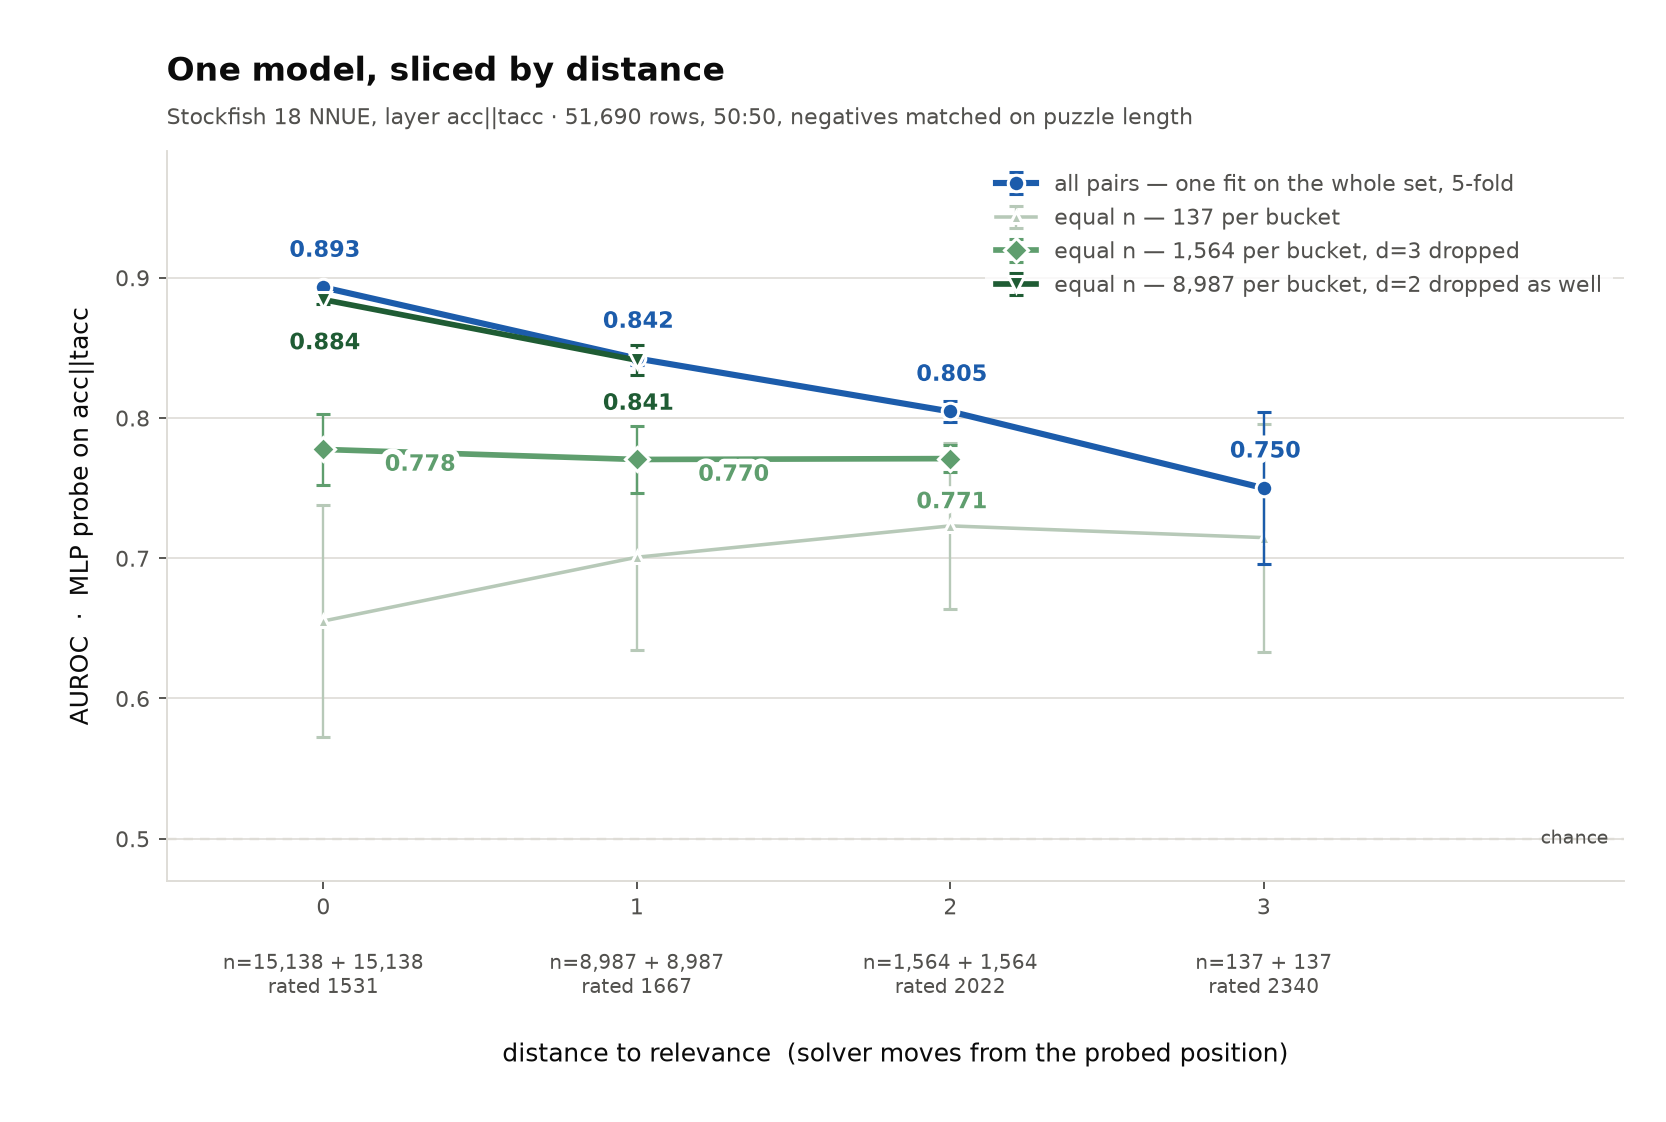

In [14]:
from IPython.display import Image, display
display(Image(filename=str(PLOT_A)))

# Part B — a separate model per distance

Nothing is shared. Each bucket gets its own `MLPClassifier`, trained only on that
bucket's positives against its length-matched negatives, 80-20 stratified split, AUROC
on that bucket's held-out fifth. Five seeds each.

## 13 · One probe per distance, all of each bucket

Training size varies with the bucket here — 30,276 rows at d=0 down to 274 at d=3.

In [15]:
def per_distance(b, seed, eq_n=None):
    """A probe trained on bucket b alone, against its length-matched negatives."""
    rng = np.random.default_rng(1000 + seed)
    pos = np.flatnonzero((y == 1) & (d == b))
    if eq_n is not None:
        pos = rng.choice(pos, eq_n, replace=False)
    neg = match_negatives(pos, rng)
    ix  = np.concatenate([pos, neg]); lab = y[ix]
    tr, te = train_test_split(np.arange(len(ix)), test_size=TEST,
                              random_state=seed, stratify=lab)
    sc, m = fit(ix[tr], lab[tr])
    a = float(roc_auc_score(lab[te], m.predict_proba(sc.transform(features()[ix[te]], copy=False))[:, 1]))
    del sc, m; gc.collect()
    return a, len(pos), len(tr)

def run_per_distance(key, buckets, reps, eq_n=None):
    if key in cached:
        print(f"  restored {key} from {EXP.name}")
        return ({int(k): v for k, v in cached[key].items()},
                {int(k): v for k, v in cached[key + "_n"].items()})
    t0 = time.time(); res, ns = {}, {}
    for b in buckets:
        v = [per_distance(b, s, eq_n) for s in range(reps)]
        res[b] = [float(np.mean([x[0] for x in v])), float(np.std([x[0] for x in v]))]
        ns[b]  = [v[0][1], v[0][2]]
        print(f"  d={b} done   {time.time()-t0:.0f}s", flush=True)
    cached[key]        = {str(k): v for k, v in res.items()}
    cached[key + "_n"] = {str(k): v for k, v in ns.items()}
    _save()
    return res, ns

own, own_n = run_per_distance("own_full", BUCKETS, 5)
print(f"\n{'d':>4} {'n_pos':>7} {'n_train':>9} {'AUROC':>8} {'sd':>7}")
for b in BUCKETS:
    print(f"{b:>4} {own_n[b][0]:>7,} {own_n[b][1]:>9,} {own[b][0]:>8.4f} {own[b][1]:>7.4f}")

  restored own_full from experiments.json

   d   n_pos   n_train    AUROC      sd
   0  15,138    24,220   0.8978  0.0039
   1   8,987    14,379   0.8248  0.0040
   2   1,564     2,502   0.7600  0.0145
   3     137       219   0.6743  0.0776


## 14 · One probe per distance, equal n, without d=3

The same separate-model design, with the training size held at **1,564** positives per
bucket — the size of d=2, so d=3 is dropped. Separate models *and* uniform n, the two
controls applied at once.

In [16]:
owneq, owneq_n = run_per_distance("own_eq1564", BUCKETS_3, 5, eq_n=1564)
print(f"\n{'d':>4} {'n_pos':>7} {'n_train':>9} {'AUROC':>8} {'sd':>7}")
for b in BUCKETS_3:
    print(f"{b:>4} {owneq_n[b][0]:>7,} {owneq_n[b][1]:>9,} {owneq[b][0]:>8.4f} {owneq[b][1]:>7.4f}")

print(f"\n{'d':>4} {'§13 own, full n':>16} {'§14 own, n=1,564':>17}")
for b in BUCKETS:
    e = f"{owneq[b][0]:>17.3f}" if b in owneq else f"{'—':>17}"
    print(f"{b:>4} {own[b][0]:>16.3f}" + e)

  restored own_eq1564 from experiments.json

   d   n_pos   n_train    AUROC      sd
   0   1,564     2,502   0.7886  0.0126
   1   1,564     2,502   0.7656  0.0163
   2   1,564     2,502   0.7572  0.0296

   d  §13 own, full n  §14 own, n=1,564
   0            0.898            0.789
   1            0.825            0.766
   2            0.760            0.757
   3            0.674                —


## 15 · One probe per distance, d=0 against d=1, equal n

The Part B counterpart to §11: separate models, 1:1 matched, and the training size held
at **8,987** positives per bucket — the size of d=1, so d=2 and d=3 are dropped. The most
data this design can put behind a single comparison.

In [17]:
owneq2, owneq2_n = run_per_distance("own_eq8987", BUCKETS_2, 5, eq_n=8987)
print(f"\n{'d':>4} {'n_pos':>7} {'n_train':>9} {'AUROC':>8} {'sd':>7}")
for b in BUCKETS_2:
    print(f"{b:>4} {owneq2_n[b][0]:>7,} {owneq2_n[b][1]:>9,} "
          f"{owneq2[b][0]:>8.4f} {owneq2[b][1]:>7.4f}")

g = owneq2[BUCKETS_2[0]][0] - owneq2[BUCKETS_2[1]][0]
sm = np.hypot(owneq2[BUCKETS_2[0]][1], owneq2[BUCKETS_2[1]][1]) / np.sqrt(5)
print(f"\nd=0 − d=1 = {g:+.4f}   ({g/sm:.1f} standard errors)"
      f"   ·  §11, one shared model: {eq8987[0][0]-eq8987[1][0]:+.4f}")

print(f"\n{'d':>4} {'§13 full n':>11} {'§14 n=1,564':>13} {'§15 n=8,987':>13}")
for b in BUCKETS:
    f = lambda t, w: f"{t[0]:>{w}.3f}" if t else f"{'—':>{w}}"
    print(f"{b:>4} {own[b][0]:>11.3f} " + f(owneq.get(b), 13) + " " + f(owneq2.get(b), 13))

  restored own_eq8987 from experiments.json

   d   n_pos   n_train    AUROC      sd
   0   8,987    14,379   0.8754  0.0059
   1   8,987    14,379   0.8317  0.0082

d=0 − d=1 = +0.0437   (9.7 standard errors)   ·  §11, one shared model: +0.0432

   d  §13 full n   §14 n=1,564   §15 n=8,987
   0       0.898         0.789         0.875
   1       0.825         0.766         0.832
   2       0.760         0.757             —
   3       0.674             —             —


## 16 · Plot — a separate model per distance

In [18]:
distance_plot(PLOT_B, "A separate model per distance", SUB, [
    ("own probe — all of each bucket", own, "#c0603a", "s", 2.6, True),
    (f"own probe — {owneq_n[BUCKETS_3[0]][0]:,} per bucket, d=3 dropped",
     owneq, "#7a3b1f", "P", 2.4, True),
    (f"own probe — {owneq2_n[BUCKETS_2[0]][0]:,} per bucket, d=2 dropped as well",
     owneq2, "#4a1f0d", "X", 2.4, True),
])

wrote distance_own.png


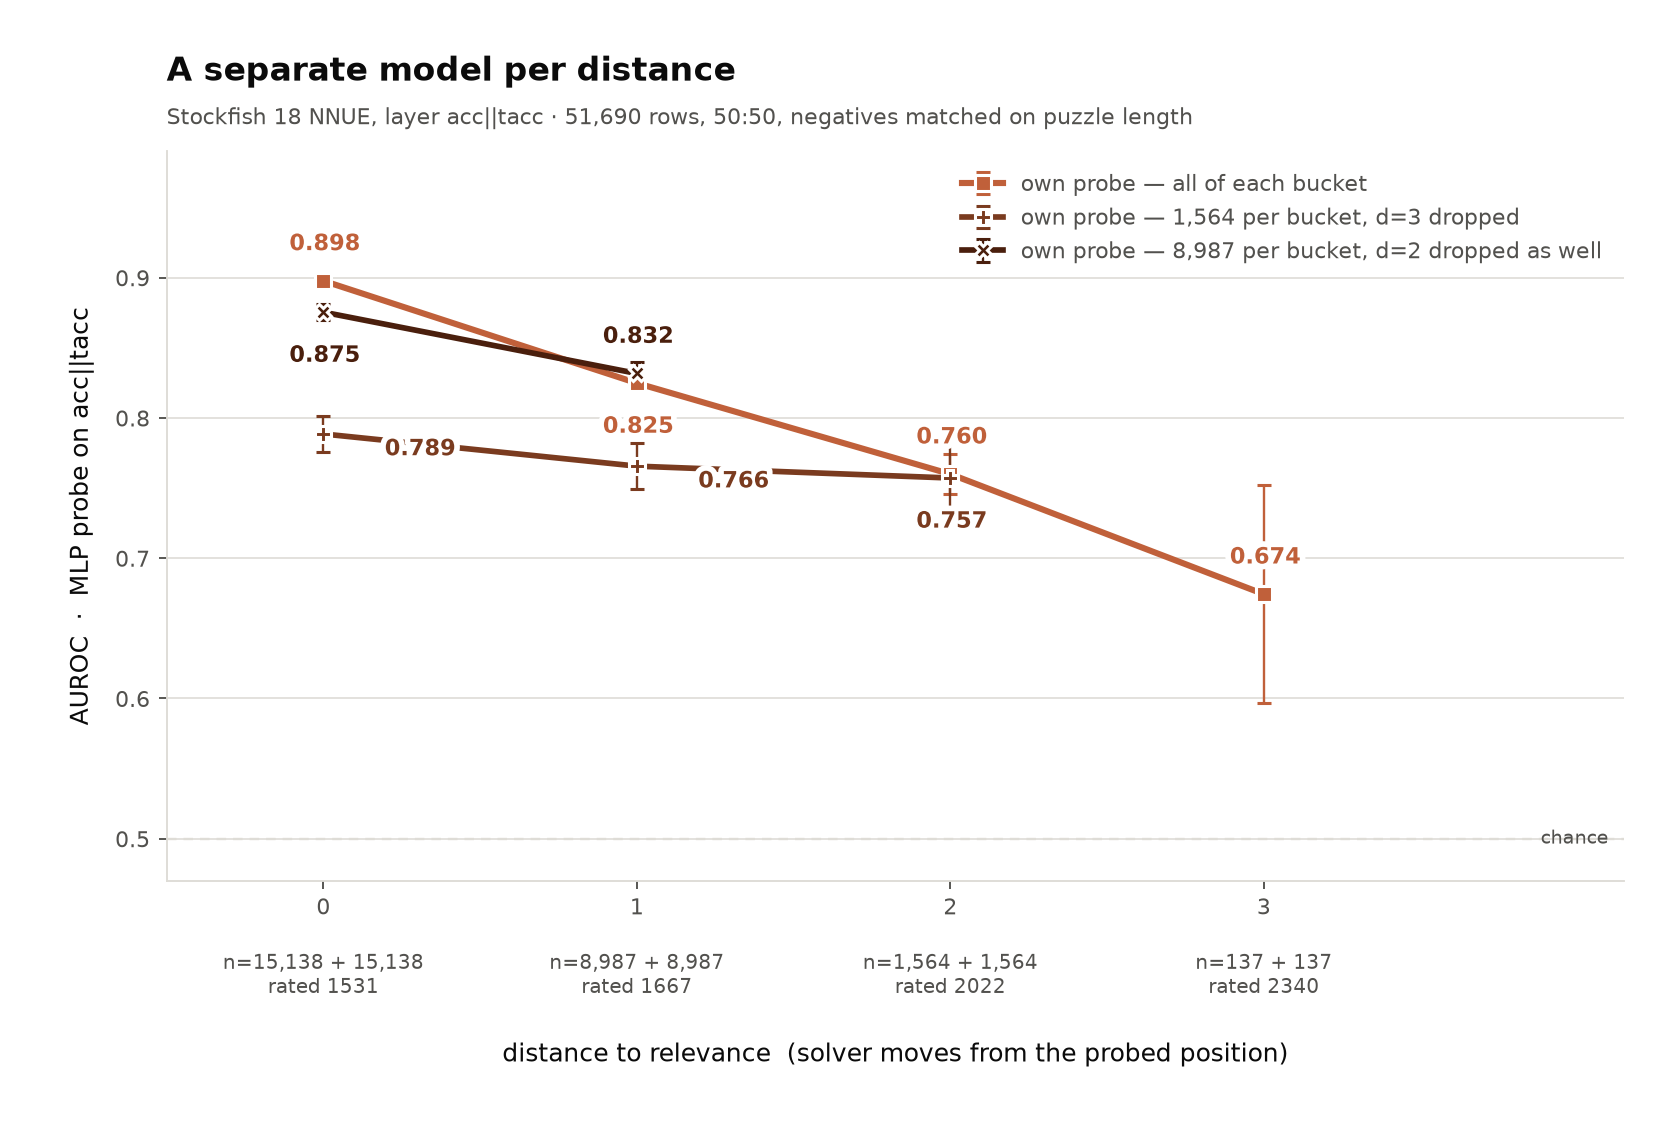

In [19]:
from IPython.display import Image, display
display(Image(filename=str(PLOT_B)))